In [ ]:
import os
import datetime
import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed

In [2]:
print("="*60)
print("STEP 0: LOAD DATA MENTAH (BELUM DI-NORMALISASI)")
print("="*60)

STEP 0: LOAD DATA MENTAH (BELUM DI-NORMALISASI)


In [3]:
path = '/content/data_training_GKU(1).csv'

In [4]:
df = pd.read_csv(path)
df.head()

,created_at,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year,month
0,2024-01-01 00:00:00,1,21.78,99.9,NaN,1.83,NaN,2024.0,1
1,2024-01-01 01:00:00,2,21.59,99.9,NaN,1.83,NaN,2024.0,1
2,2024-01-01 02:00:00,3,21.44,99.9,NaN,1.82,132.09,2024.0,1
3,2024-01-01 03:00:00,4,21.25,99.9,NaN,1.81,117.92,2024.0,1
4,2024-01-01 04:00:00,5,21.12,99.9,NaN,1.81,114.37,2024.0,1


In [5]:
if 'created_at' in df.columns:
    df['created_at'] = pd.to_datetime(df['created_at'])
    df = df.set_index('created_at')
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

print("Sample data mentah:")
print(df[['temperature', 'humidity', 'pm25']].head())
print(f"\nShape: {df.shape}")

Sample data mentah:
                     temperature  humidity    pm25
created_at                                        
2024-01-01 00:00:00        21.78      99.9     NaN
2024-01-01 01:00:00        21.59      99.9     NaN
2024-01-01 02:00:00        21.44      99.9  132.09
2024-01-01 03:00:00        21.25      99.9  117.92
2024-01-01 04:00:00        21.12      99.9  114.37

Shape: (15338, 8)


In [6]:
print("\n" + "="*60)
print("STEP 1: INTERPOLASI DATA")
print("="*60)

cols = ['temperature', 'humidity', 'pm25']

# Cek NaN
print(f"NaN sebelum: {df[cols].isna().sum().to_dict()}")

# Interpolasi jika perlu
if df[cols].isna().any().any():
    full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
    df = df.reindex(full_range)
    df = df.infer_objects(copy=False)
    df = df.interpolate(method='time')
    df = df.dropna(subset=['pm25'])  # Drop jika masih ada NaN di target

    print(f"NaN setelah: {df[cols].isna().sum().to_dict()}")
else:
    print("Tidak ada NaN, skip interpolasi")

# Reset index untuk memudahkan
df = df.reset_index().rename(columns={'index': 'created_at'})
df = df.copy()  # Simpan untuk proses selanjutnya


STEP 1: INTERPOLASI DATA
NaN sebelum: {'temperature': 559, 'humidity': 266, 'pm25': 991}
NaN setelah: {'temperature': 0, 'humidity': 0, 'pm25': 0}


In [7]:
df.head()

,created_at,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year,month
0,2024-01-01 02:00:00,3.0,21.44,99.9,NaN,1.82,132.09,2024.0,1.0
1,2024-01-01 03:00:00,4.0,21.25,99.9,NaN,1.81,117.92,2024.0,1.0
2,2024-01-01 04:00:00,5.0,21.12,99.9,NaN,1.81,114.37,2024.0,1.0
3,2024-01-01 05:00:00,6.0,21.25,99.9,NaN,1.81,95.11,2024.0,1.0
4,2024-01-01 06:00:00,7.0,23.03,99.9,NaN,1.82,125.77,2024.0,1.0


### Feature Engineer

#### Circular Encoding
Dalam menggunakan Circular Encoding, model LSTM terhadap konteks waktu siklus. Dengan fitur ini, Anda mengubah data "mati" menjadi fitur geografis-waktu yang sangat kuat untuk memprediksi fluktuasi polusi.

In [8]:
df['created_at'] = pd.to_datetime(df['created_at'])
timestamp_s = df['created_at'].map(pd.Timestamp.timestamp)
day = 24*60*60
year=(365.2425)*day

df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

Text(0.5, 1.0, 'Time of day signal')

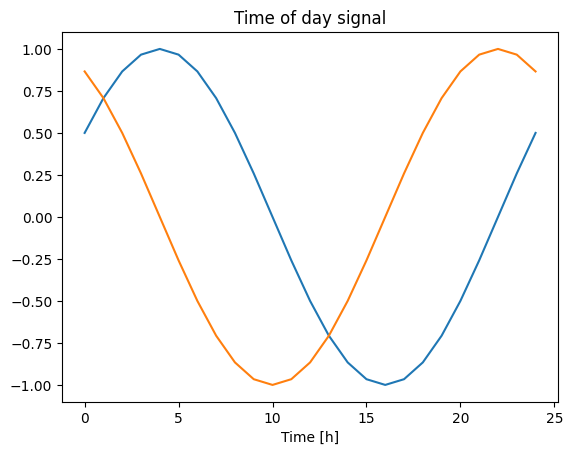

In [9]:
plt.plot(np.array(df['Day sin'])[:25])
plt.plot(np.array(df['Day cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

In [10]:
df_f = df.drop(columns=['created_at', 'id', 'year', 'month','sht31_temp','sht31_hum'])

In [11]:
df_f.head()

,temperature,humidity,pm25,Day sin,Day cos,Year sin,Year cos
0,21.44,99.9,132.09,0.500000,8.660254e-01,-0.000201,1.000000
1,21.25,99.9,117.92,0.707107,7.071068e-01,0.000516,1.000000
2,21.12,99.9,114.37,0.866025,5.000000e-01,0.001233,0.999999
3,21.25,99.9,95.11,0.965926,2.588190e-01,0.001950,0.999998
4,23.03,99.9,125.77,1.000000,1.944223e-12,0.002666,0.999996


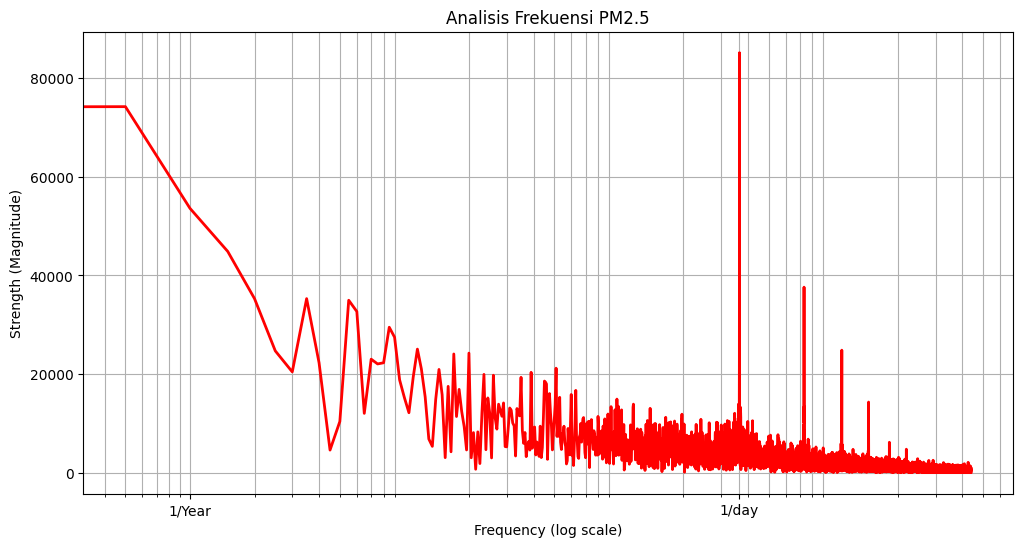

In [12]:
from scipy.fft import rfft, rfftfreq
import matplotlib.pyplot as plt
import numpy as np


data = df_f['pm25'].dropna().values

n = len(data)
yf = rfft(data - np.mean(data))
xf = rfftfreq(n, 1/24)

xf_year = xf * 365.25

plt.figure(figsize=(12, 6))
plt.semilogx(xf_year, np.abs(yf), linewidth=2, color='red')

plt.xticks([1, 365.25], labels=['1/Year', '1/day'])
plt.grid(True, which="both")
plt.xlabel('Frequency (log scale)')
plt.ylabel('Strength (Magnitude)')
plt.title('Analisis Frekuensi PM2.5')
plt.show()

Split the preprocessed df_f dataframe into training (70%), validation (20%), and testing (10%) sets sequentially by calculating the appropriate split indices.

In [13]:
print("\n" + "="*60)
print("STEP 2: SPLIT DATA (70/20/10)")
print("="*60)

n = len(df_f)
train_df = df_f[0:int(n*0.7)].copy()
val_df = df_f[int(n*0.7):int(n*0.9)].copy()
test_df = df_f[int(n*0.9):].copy()

print(f"Total: {n}")
print(f"Train: {len(train_df)} ({len(train_df)/n*100:.1f}%)")
print(f"Val:   {len(val_df)} ({len(val_df)/n*100:.1f}%)")
print(f"Test:  {len(test_df)} ({len(test_df)/n*100:.1f}%)")


STEP 2: SPLIT DATA (70/20/10)
Total: 17542
Train: 12279 (70.0%)
Val:   3508 (20.0%)
Test:  1755 (10.0%)


In [14]:
total = len(df_f)
print(f"Persentase Training: {(len(train_df)/total)*100:.2f}%")
print(f"Persentase Validation: {(len(val_df)/total)*100:.2f}%")
print(f"Persentase Testing: {(len(test_df)/total)*100:.2f}%")

Persentase Training: 70.00%
Persentase Validation: 20.00%
Persentase Testing: 10.00%


In [15]:
print("\n" + "="*60)
print("STEP 3: ANALISIS OUTLIER (DATA MENTAH)")
print("="*60)

def analyze_outliers(df, name):
    print(f"\n📊 {name}:")
    for col in cols:
        data = df[col]
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = data[(data < lower) | (data > upper)]

        print(f"  {col}:")
        print(f"     Range: [{data.min():.2f}, {data.max():.2f}]")
        print(f"     Mean: {data.mean():.2f}, Std: {data.std():.2f}")
        print(f"     Outlier IQR: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

analyze_outliers(train_df, "TRAIN (mentah)")
analyze_outliers(val_df, "VAL (mentah)")
analyze_outliers(test_df, "TEST (mentah)")


STEP 3: ANALISIS OUTLIER (DATA MENTAH)

📊 TRAIN (mentah):
  temperature:
     Range: [17.62, 40.40]
     Mean: 26.60, Std: 4.27
     Outlier IQR: 8 (0.07%)
  humidity:
     Range: [12.23, 100.00]
     Mean: 77.96, Std: 18.96
     Outlier IQR: 10 (0.08%)
  pm25:
     Range: [0.00, 156.11]
     Mean: 49.26, Std: 23.98
     Outlier IQR: 382 (3.11%)

📊 VAL (mentah):
  temperature:
     Range: [18.92, 39.82]
     Mean: 28.10, Std: 4.34
     Outlier IQR: 0 (0.00%)
  humidity:
     Range: [25.57, 89.64]
     Mean: 64.78, Std: 14.25
     Outlier IQR: 0 (0.00%)
  pm25:
     Range: [2.47, 147.97]
     Mean: 57.84, Std: 23.75
     Outlier IQR: 30 (0.86%)

📊 TEST (mentah):
  temperature:
     Range: [22.41, 39.57]
     Mean: 27.26, Std: 3.58
     Outlier IQR: 197 (11.23%)
  humidity:
     Range: [33.74, 89.33]
     Mean: 67.12, Std: 13.91
     Outlier IQR: 0 (0.00%)
  pm25:
     Range: [4.47, 110.38]
     Mean: 47.78, Std: 18.87
     Outlier IQR: 38 (2.17%)


In [16]:
print("\n" + "="*60)
print("STEP 4: HANDLING OUTLIER (CAPPING)")
print("="*60)

# Cek apakah perlu capping
HANDLE_OUTLIER = True

if HANDLE_OUTLIER:
    # Gunakan percentile 1% dan 99% dari TRAIN
    cap_params = {}
    for col in cols:
        lower = train_df[col].quantile(0.01)
        upper = train_df[col].quantile(0.99)
        cap_params[col] = (lower, upper)

        print(f"{col}: cap ke [{lower:.2f}, {upper:.2f}]")

        # Apply ke semua split
        train_df[col] = train_df[col].clip(lower, upper)
        val_df[col] = val_df[col].clip(lower, upper)
        test_df[col] = test_df[col].clip(lower, upper)

    print("\nSetelah capping:")
    analyze_outliers(train_df, "TRAIN (capped)")


STEP 4: HANDLING OUTLIER (CAPPING)
temperature: cap ke [20.33, 36.67]
humidity: cap ke [27.98, 100.00]
pm25: cap ke [6.68, 121.04]

Setelah capping:

📊 TRAIN (capped):
  temperature:
     Range: [20.33, 36.67]
     Mean: 26.60, Std: 4.23
     Outlier IQR: 0 (0.00%)
  humidity:
     Range: [27.98, 100.00]
     Mean: 78.01, Std: 18.82
     Outlier IQR: 0 (0.00%)
  pm25:
     Range: [6.68, 121.04]
     Mean: 49.16, Std: 23.46
     Outlier IQR: 382 (3.11%)


### Normalize Data

In [17]:
from sklearn.preprocessing import StandardScaler
import joblib
print("\n" + "="*60)
print("STEP 5: STANDARDSCALER")
print("="*60)

# Fit hanya di TRAIN
scaler = StandardScaler()
scaler.fit(train_df[cols])

print("Parameter scaler (dari train):")
for i, col in enumerate(cols):
    print(f"  {col}: μ={scaler.mean_[i]:.3f}, σ={scaler.scale_[i]:.3f}")

# Transform ke semua split
train_scaled = train_df.copy()
val_scaled = val_df.copy()
test_scaled = test_df.copy()

train_scaled[cols] = scaler.transform(train_df[cols])
val_scaled[cols] = scaler.transform(val_df[cols])
test_scaled[cols] = scaler.transform(test_df[cols])


STEP 5: STANDARDSCALER
Parameter scaler (dari train):
  temperature: μ=26.595, σ=4.230
  humidity: μ=78.010, σ=18.824
  pm25: μ=49.161, σ=23.455


In [18]:
print("\n" + "="*60)
print("STEP 6: VERIFIKASI HASIL")
print("="*60)

def verify(df, name):
    print(f"\n✅ {name}:")
    for col in cols:
        mean = df[col].mean()
        std = df[col].std()
        min_v = df[col].min()
        max_v = df[col].max()

        # Hitung outlier |z| > 3
        z_outliers = (df[col].abs() > 3).sum()

        print(f"  {col}: μ={mean:.4f}, σ={std:.4f}, range=[{min_v:.3f}, {max_v:.3f}], |z|>3: {z_outliers}")

verify(train_scaled, "TRAIN")
verify(val_scaled, "VAL")
verify(test_scaled, "TEST")


STEP 6: VERIFIKASI HASIL

✅ TRAIN:
  temperature: μ=-0.0000, σ=1.0000, range=[-1.481, 2.382], |z|>3: 0
  humidity: μ=-0.0000, σ=1.0000, range=[-2.658, 1.168], |z|>3: 0
  pm25: μ=-0.0000, σ=1.0000, range=[-1.811, 3.065], |z|>3: 142

✅ VAL:
  temperature: μ=0.3478, σ=1.0059, range=[-1.481, 2.382], |z|>3: 0
  humidity: μ=-0.7028, σ=0.7570, range=[-2.658, 0.618], |z|>3: 0
  pm25: μ=0.3665, σ=1.0011, range=[-1.811, 3.065], |z|>3: 38

✅ TEST:
  temperature: μ=0.1487, σ=0.8244, range=[-0.989, 2.382], |z|>3: 0
  humidity: μ=-0.5786, σ=0.7389, range=[-2.352, 0.601], |z|>3: 0
  pm25: μ=-0.0587, σ=0.8043, range=[-1.811, 2.610], |z|>3: 0



STEP 7: VISUALISASI


/tmp/ipython-input-505/2585206484.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot([train_df[col], val_df[col], test_df[col]],
/tmp/ipython-input-505/2585206484.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot([train_scaled[col], val_scaled[col], test_scaled[col]],
/tmp/ipython-input-505/2585206484.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot([train_df[col], val_df[col], test_df[col]],
/tmp/ipython-input-505/2585206484.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; suppor

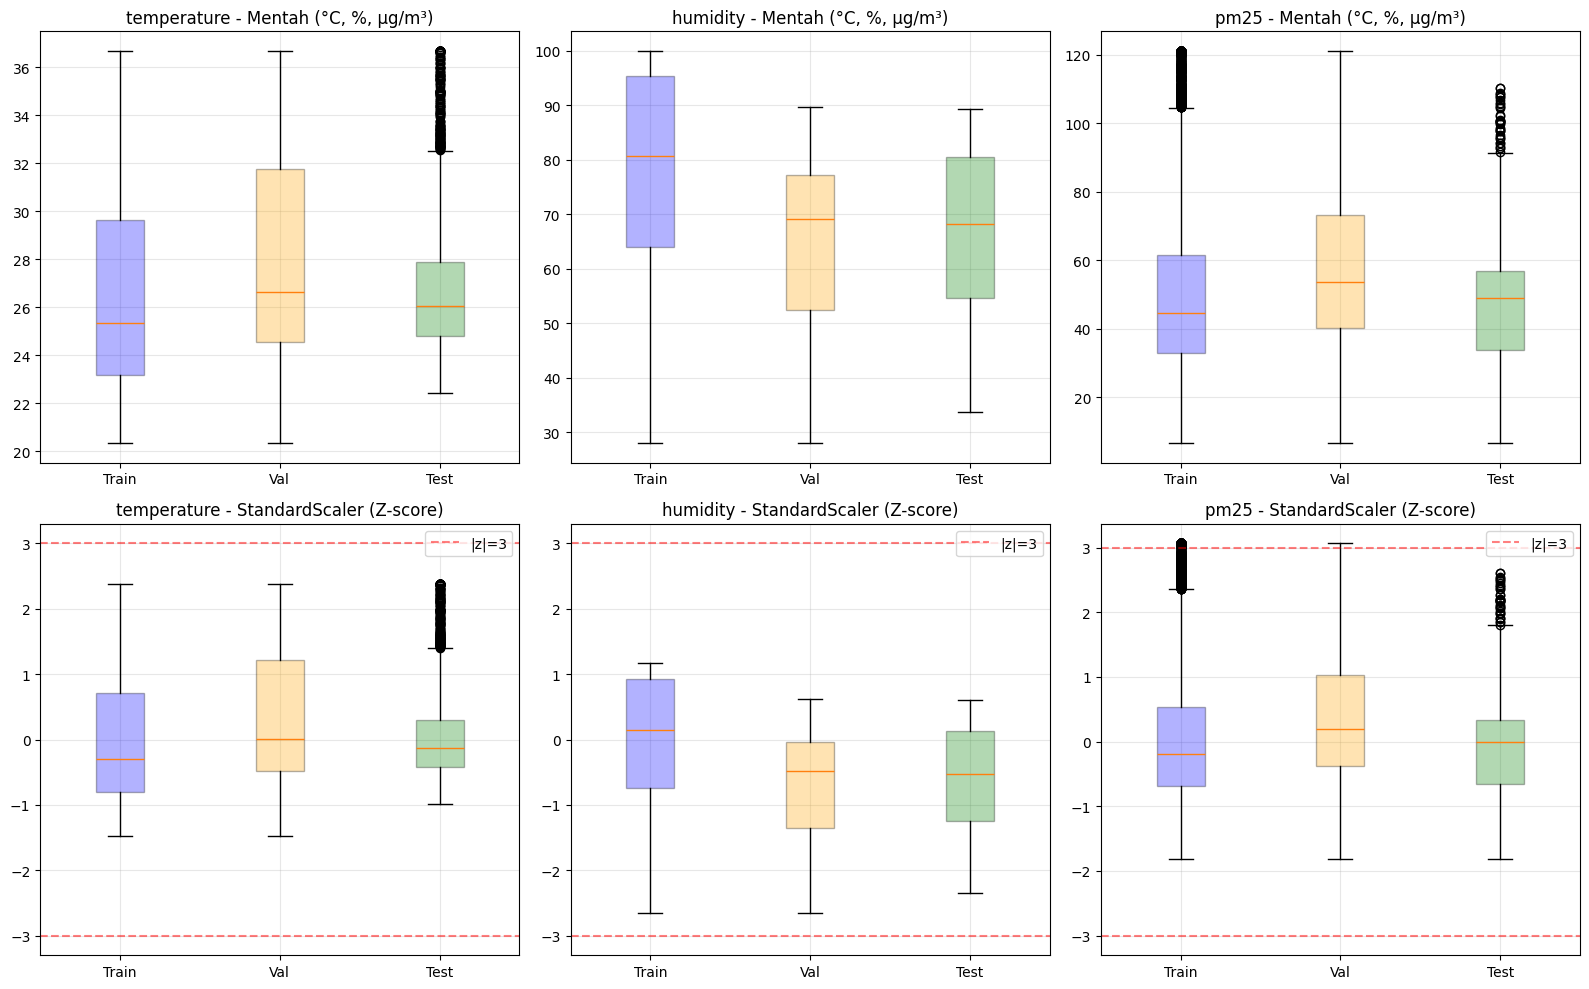

In [19]:
print("\n" + "="*60)
print("STEP 7: VISUALISASI")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for idx, col in enumerate(cols):
    # Before scaling
    ax1 = axes[0, idx]
    bp1 = ax1.boxplot([train_df[col], val_df[col], test_df[col]],
                      labels=['Train', 'Val', 'Test'], patch_artist=True)
    for patch, color in zip(bp1['boxes'], ['blue', 'orange', 'green']):
        patch.set_facecolor(color)
        patch.set_alpha(0.3)
    ax1.set_title(f'{col} - Mentah (°C, %, μg/m³)')
    ax1.grid(True, alpha=0.3)

    # After scaling
    ax2 = axes[1, idx]
    bp2 = ax2.boxplot([train_scaled[col], val_scaled[col], test_scaled[col]],
                      labels=['Train', 'Val', 'Test'], patch_artist=True)
    for patch, color in zip(bp2['boxes'], ['blue', 'orange', 'green']):
        patch.set_facecolor(color)
        patch.set_alpha(0.3)
    ax2.set_title(f'{col} - StandardScaler (Z-score)')
    ax2.axhline(y=3, color='r', linestyle='--', alpha=0.5, label='|z|=3')
    ax2.axhline(y=-3, color='r', linestyle='--', alpha=0.5)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
print("\n" + "="*60)
print("STEP 8: SIMPAN HASIL")
print("="*60)

# Assign hasil akhir
train_df = train_scaled
val_df = val_scaled
test_df = test_scaled

# Simpan scaler dan cap_params untuk inference
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(cap_params, 'cap_params.pkl')

print("✅ train_df, val_df, test_df siap digunakan!")
print("✅ scaler.pkl dan cap_params.pkl disimpan!")

# Cek final
print(f"\nFinal shapes:")
print(f"  Train: {train_df.shape}")
print(f"  Val:   {val_df.shape}")
print(f"  Test:  {test_df.shape}")


STEP 8: SIMPAN HASIL
✅ train_df, val_df, test_df siap digunakan!
✅ scaler.pkl dan cap_params.pkl disimpan!

Final shapes:
  Train: (12279, 7)
  Val:   (3508, 7)
  Test:  (1755, 7)


PERBAIKAN: TAMBAH FITUR LAGGED PM2.5
Fitur yang tersedia:
['temperature', 'humidity', 'pm25', 'Day sin', 'Day cos', 'Year sin', 'Year cos', 'pm25_lag_1', 'pm25_lag_2', 'pm25_lag_3', 'pm25_lag_6', 'pm25_lag_12', 'pm25_lag_24']


/tmp/ipython-input-505/1615756178.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')
/tmp/ipython-input-505/1615756178.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')
/tmp/ipython-input-505/1615756178.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')



Input shape: (32, 72, 8), Label shape: (32, 24, 1)

Model summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 72, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 72, 128)        │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 24, 1)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,688 (537.84 KB)

 Trainable params: 137,688 (537.84 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING
Epoch 1/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.7217 - mae: 0.6526 - val_loss: 0.8939 - val_mae: 0.7455 - learning_rate: 0.0010
Epoch 2/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.5767 - mae: 0.5805 - val_loss: 0.9540 - val_mae: 0.7627 - learning_rate: 0.0010
Epoch 3/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.5106 - mae: 0.5470 - val_loss: 0.9628 - val_mae: 0.7561 - learning_rate: 0.0010
Epoch 4/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.4463 - mae: 0.5120 - val_loss: 0.9861 - val_mae: 0.7669 - learning_rate: 0.0010
Epoch 5/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.3960 - mae: 0.4819 - val_loss: 1.0234 - val_mae: 0.7831 - learning_rate: 0.0010
Epoch 6/100
380/381 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3425 - mae: 0.4473
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.3425 - mae: 0.4473 - val_loss: 0.9940 - val_mae: 0.7813 - 

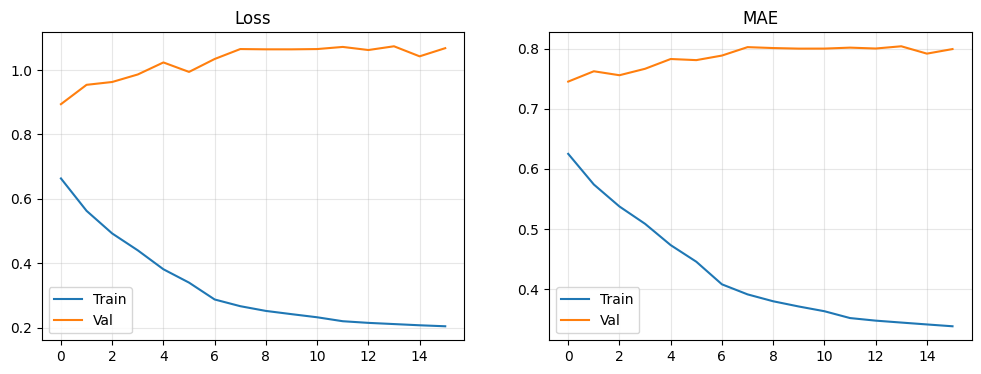


Metrics:
    horizon   mae_z      r2   mae_ug
0         1  0.4315  0.4437  10.1212
1         2  0.4677  0.3712  10.9706
2         3  0.4892  0.3240  11.4745
3         4  0.4838  0.3094  11.3474
4         5  0.4969  0.2729  11.6543
5         6  0.5073  0.2558  11.8996
6         7  0.5213  0.2255  12.2269
7         8  0.5252  0.2117  12.3179
8         9  0.5322  0.1922  12.4828
9        10  0.5307  0.1959  12.4471
10       11  0.5288  0.1937  12.4031
11       12  0.5306  0.2019  12.4448
12       13  0.5329  0.1950  12.5005
13       14  0.5324  0.1893  12.4881
14       15  0.5318  0.1874  12.4731
15       16  0.5379  0.1887  12.6173
16       17  0.5392  0.1814  12.6479
17       18  0.5358  0.1961  12.5680
18       19  0.5366  0.2005  12.5871
19       20  0.5466  0.1812  12.8197
20       21  0.5451  0.1935  12.7850
21       22  0.5424  0.2046  12.7213
22       23  0.5492  0.1864  12.8824
23       24  0.5450  0.1909  12.7842

SUMMARY:
Short (1-6): MAE=0.4794 (z) / 11.24 μg/m³, R²=0.3295
Me

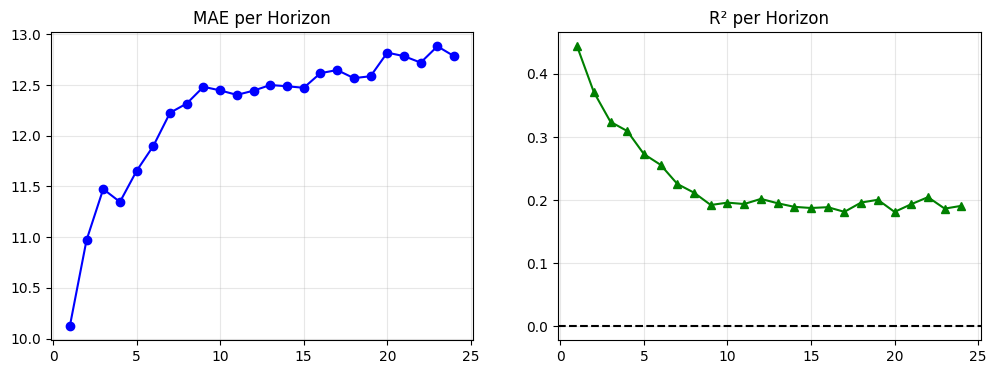


✅ Model disimpan!


In [21]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

print("="*60)
print("PERBAIKAN: TAMBAH FITUR LAGGED PM2.5")
print("="*60)

# ============================================
# STEP 1: BUAT FITUR LAGGED
# ============================================

def create_lagged_features(df, lags=[1, 2, 3, 6, 12, 24]):
    """Buat fitur lagged PM2.5"""
    df = df.copy()
    for lag in lags:
        df[f'pm25_lag_{lag}'] = df['pm25'].shift(lag)

    # Forward fill untuk NaN awal
    df = df.fillna(method='bfill')
    return df

# Apply ke semua split
train_features = create_lagged_features(train_scaled)
val_features = create_lagged_features(val_scaled)
test_features = create_lagged_features(test_scaled)

print("Fitur yang tersedia:")
print(train_features.columns.tolist())

# ============================================
# STEP 2: WINDOW GENERATOR DENGAN FITUR BARU
# ============================================

FEATURE_COLS = ['temperature', 'humidity', 'pm25_lag_1', 'pm25_lag_2', 'pm25_lag_3', 'pm25_lag_6', 'pm25_lag_12', 'pm25_lag_24']
LABEL_COLS = ['pm25']

class WindowGenerator():
    def __init__(self, input_width, label_width, shift,
                 train_df, val_df, test_df,
                 feature_columns, label_columns):

        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df

        self.feature_columns = feature_columns
        self.label_columns = label_columns

        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift + label_width - 1
        self.all_columns = feature_columns + label_columns

    def split_window(self, features):
        inputs = features[:, :self.input_width, :len(self.feature_columns)]
        label_start = self.input_width + self.shift - 1
        labels = features[:, label_start:label_start + self.label_width, len(self.feature_columns):]
        return inputs, labels

    def make_dataset(self, data, shuffle=True):
        data_array = data[self.all_columns].values.astype(np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data_array,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=shuffle,
            batch_size=32,
        )
        return ds.map(self.split_window)

    @property
    def train(self):
        return self.make_dataset(self.train_df, shuffle=True)

    @property
    def val(self):
        return self.make_dataset(self.val_df, shuffle=False)

    @property
    def test(self):
        return self.make_dataset(self.test_df, shuffle=False)

multi_window = WindowGenerator(
    input_width=72,
    label_width=24,
    shift=1,
    train_df=train_features,
    val_df=val_features,
    test_df=test_features,
    feature_columns=FEATURE_COLS,
    label_columns=LABEL_COLS
)

# Verifikasi
for inputs, labels in multi_window.train.take(1):
    print(f"\nInput shape: {inputs.shape}, Label shape: {labels.shape}")

# ============================================
# STEP 3: MODEL LSTM (KARENA ADA SEKUENSIAL)
# ============================================

def build_lstm_model(input_width, label_width, n_features):
    """Model LSTM untuk capture temporal patterns"""
    inputs = layers.Input(shape=(input_width, n_features))

    # LSTM layers
    x = layers.LSTM(128, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(64, return_sequences=False)(x)
    x = layers.Dropout(0.2)(x)

    # Dense
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)

    outputs = layers.Dense(label_width)(x)
    outputs = layers.Reshape((label_width, 1))(outputs)

    return Model(inputs, outputs)

model = build_lstm_model(72, 24, len(FEATURE_COLS))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("\nModel summary:")
model.summary()

# ============================================
# STEP 4: TRAINING
# ============================================

print("\n" + "="*60)
print("TRAINING")
print("="*60)

history = model.fit(
    multi_window.train,
    validation_data=multi_window.val,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train')
axes[1].plot(history.history['val_mae'], label='Val')
axes[1].set_title('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.show()

# ============================================
# STEP 5: EVALUASI
# ============================================

def evaluate(model, window_gen, scaler):
    all_preds, all_labels = [], []

    for inputs, labels in window_gen.test:
        preds = model.predict(inputs, verbose=0)
        all_preds.append(preds)
        all_labels.append(labels.numpy())

    preds = np.concatenate(all_preds, axis=0).squeeze(-1)
    labels = np.concatenate(all_labels, axis=0).squeeze(-1)

    metrics = []
    for h in range(24):
        mae = np.mean(np.abs(preds[:, h] - labels[:, h]))
        rmse = np.sqrt(np.mean((preds[:, h] - labels[:, h])**2))

        ss_res = np.sum((labels[:, h] - preds[:, h])**2)
        ss_tot = np.sum((labels[:, h] - np.mean(labels[:, h]))**2)
        r2 = 1 - (ss_res / (ss_tot + 1e-8))

        pm25_std = scaler.scale_[2]

        metrics.append({
            'horizon': h+1,
            'mae_z': mae,
            'r2': r2,
            'mae_ug': mae * pm25_std
        })

    return pd.DataFrame(metrics), preds, labels

metrics_df, preds, labels = evaluate(model, multi_window, scaler)

print("\nMetrics:")
print(metrics_df.round(4))

print("\nSUMMARY:")
for name, idx in [('Short (1-6)', range(6)), ('Medium (7-12)', range(6,12)), ('Long (13-24)', range(12,24))]:
    mae_z = metrics_df.iloc[list(idx)]['mae_z'].mean()
    r2 = metrics_df.iloc[list(idx)]['r2'].mean()
    mae_ug = metrics_df.iloc[list(idx)]['mae_ug'].mean()
    print(f"{name}: MAE={mae_z:.4f} (z) / {mae_ug:.2f} μg/m³, R²={r2:.4f}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(metrics_df['horizon'], metrics_df['mae_ug'], 'b-o')
axes[0].set_title('MAE per Horizon')
axes[0].grid(True, alpha=0.3)

axes[1].plot(metrics_df['horizon'], metrics_df['r2'], 'g-^')
axes[1].axhline(y=0, color='k', linestyle='--')
axes[1].set_title('R² per Horizon')
axes[1].grid(True, alpha=0.3)
plt.show()

model.save('pm25_model_lagged.keras')
print("\n✅ Model disimpan!")

PREDIKSI 1 JAM KE DEPAN - TARGET R² > 0.5
Membuat fitur lagged...

Jumlah fitur: 13

✅ Input shape: (32, 72, 6), Label shape: (32, 1, 1)
Input: 72 jam history x 6 fitur
Output: 1 jam prediksi PM2.5

MODEL SUMMARY


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 72, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 72, 256)        │       138,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 72, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 72, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 72, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 444,161 (1.69 MB)

 Trainable params: 443,393 (1.69 MB)

 Non-trainable params: 768 (3.00 KB)


TRAINING
Epoch 1/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.0195 - mae: 0.7719Epoch 0: val_loss=0.5644, val_R²=-4957.3516
382/382 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - loss: 1.0188 - mae: 0.7717 - val_loss: 0.5644 - val_mae: 0.5752 - learning_rate: 0.0010
Epoch 2/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.4992 - mae: 0.5391 - val_loss: 0.5619 - val_mae: 0.5823 - learning_rate: 0.0010
Epoch 3/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.4628 - mae: 0.5141 - val_loss: 0.4625 - val_mae: 0.5229 - learning_rate: 0.0010
Epoch 4/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.3922 - mae: 0.4729 - val_loss: 0.4423 - val_mae: 0.5022 - learning_rate: 0.0010
Epoch 5/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.3924 - mae: 0.4703 - val_loss: 0.4572 - val_mae: 0.5057 - learning_rate: 0.0010
Epoch 6/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.3744 - mae: 0.4578 - val_loss: 0.4516 - val_mae: 0.5071 - learning_rate: 0.0010
Epoch 7

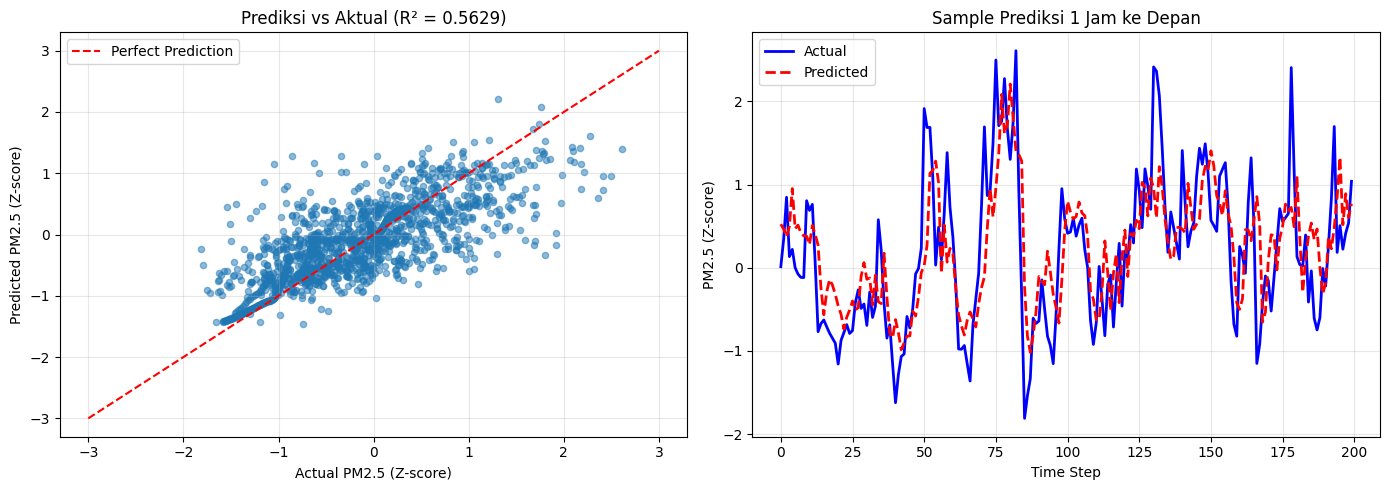


ERROR ANALYSIS
Error mean: -0.0440 (harus ~0)
Error std:  0.5047
Error range: [-2.19, 2.13]

✅ Model disimpan ke 'pm25_model_1hour.keras'
✅ Target R² > 0.5: TERCAPAI


In [22]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

print("="*60)
print("PREDIKSI 1 JAM KE DEPAN - TARGET R² > 0.5")
print("="*60)

# ============================================
# STEP 1: BUAT FITUR LAGGED (FOKUS PADA LAG PENDEK)
# ============================================

def create_lagged_features(df, lags=[1, 2, 3, 6, 12, 24]):
    """Buat fitur lagged PM2.5"""
    df = df.copy()
    for lag in lags:
        df[f'pm25_lag_{lag}'] = df['pm25'].shift(lag)

    # Forward fill untuk NaN awal
    df = df.bfill()
    return df

print("Membuat fitur lagged...")
train_features = create_lagged_features(train_scaled)
val_features = create_lagged_features(val_scaled)
test_features = create_lagged_features(test_scaled)

print(f"\nJumlah fitur: {train_features.shape[1]}")

# ============================================
# STEP 2: WINDOW GENERATOR UNTUK 1 JAM PREDIKSI
# ============================================

# UNTUK 1 JAM: label_width=1, shift=1
FEATURE_COLS = ['temperature', 'humidity', 'pm25_lag_1', 'pm25_lag_2', 'pm25_lag_3', 'pm25_lag_6']
LABEL_COLS = ['pm25']

class WindowGenerator():
    def __init__(self, input_width, label_width, shift,
                 train_df, val_df, test_df,
                 feature_columns, label_columns):

        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df

        self.feature_columns = feature_columns
        self.label_columns = label_columns

        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift + label_width - 1
        self.all_columns = feature_columns + label_columns

    def split_window(self, features):
        inputs = features[:, :self.input_width, :len(self.feature_columns)]
        label_start = self.input_width + self.shift - 1
        labels = features[:, label_start:label_start + self.label_width, len(self.feature_columns):]
        return inputs, labels

    def make_dataset(self, data, shuffle=True):
        data_array = data[self.all_columns].values.astype(np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data_array,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=shuffle,
            batch_size=32,
        )
        return ds.map(self.split_window)

    @property
    def train(self):
        return self.make_dataset(self.train_df, shuffle=True)

    @property
    def val(self):
        return self.make_dataset(self.val_df, shuffle=False)

    @property
    def test(self):
        return self.make_dataset(self.test_df, shuffle=False)

# KONFIGURASI UNTUK 1 JAM PREDIKSI
multi_window = WindowGenerator(
    input_width=72,      # 72 jam history
    label_width=1,       # 1 jam prediksi (BUKAN 24!)
    shift=1,             # 1 jam ke depan
    train_df=train_features,
    val_df=val_features,
    test_df=test_features,
    feature_columns=FEATURE_COLS,
    label_columns=LABEL_COLS
)

# Verifikasi
for inputs, labels in multi_window.train.take(1):
    print(f"\n✅ Input shape: {inputs.shape}, Label shape: {labels.shape}")
    print(f"Input: 72 jam history x {len(FEATURE_COLS)} fitur")
    print(f"Output: 1 jam prediksi PM2.5")

# ============================================
# STEP 3: MODEL LSTM YANG LEBIH KUAT
# ============================================

def build_strong_lstm(input_width, n_features):
    """Model LSTM lebih kuat untuk 1 jam prediksi"""
    inputs = layers.Input(shape=(input_width, n_features))

    # Bidirectional LSTM untuk capture pattern lebih baik
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(inputs)
    x = layers.Dropout(0.3)(x)

    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.LSTM(64, return_sequences=False)(x)
    x = layers.Dropout(0.2)(x)

    # Dense layers lebih besar
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(64, activation='relu')(x)

    # Output: 1 nilai (1 jam)
    outputs = layers.Dense(1)(x)

    return Model(inputs, outputs)

model = build_strong_lstm(72, len(FEATURE_COLS))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
model.summary()

# ============================================
# STEP 4: TRAINING DENGAN MONITORING R²
# ============================================

print("\n" + "="*60)
print("TRAINING")
print("="*60)

class R2Callback(tf.keras.callbacks.Callback):
    """Callback untuk monitoring R²"""
    def on_epoch_end(self, epoch, logs=None):
        if epoch % 10 == 0:
            # Hitung R² di validation set
            val_preds = []
            val_labels = []
            for inputs, labels in multi_window.val:
                preds = self.model.predict(inputs, verbose=0)
                val_preds.append(preds)
                val_labels.append(labels.numpy())

            val_preds = np.concatenate(val_preds)
            val_labels = np.concatenate(val_labels)

            ss_res = np.sum((val_labels - val_preds)**2)
            ss_tot = np.sum((val_labels - np.mean(val_labels))**2)
            r2 = 1 - (ss_res / ss_tot)

            print(f"Epoch {epoch}: val_loss={logs['val_loss']:.4f}, val_R²={r2:.4f}")

history = model.fit(
    multi_window.train,
    validation_data=multi_window.val,
    epochs=100,
    callbacks=[
        R2Callback(),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=1e-7,
            verbose=1
        )
    ]
)

# ============================================
# STEP 5: EVALUASI DETAIL
# ============================================

print("\n" + "="*60)
print("EVALUASI FINAL")
print("="*60)

def evaluate_detailed(model, window_gen, scaler):
    all_preds, all_labels = [], []

    for inputs, labels in window_gen.test:
        preds = model.predict(inputs, verbose=0)
        all_preds.append(preds)
        all_labels.append(labels.numpy())

    preds = np.concatenate(all_preds).flatten()
    labels = np.concatenate(all_labels).flatten()

    # Metrics
    mae = np.mean(np.abs(preds - labels))
    rmse = np.sqrt(np.mean((preds - labels)**2))
    mape = np.mean(np.abs((labels - preds) / (labels + 1e-8))) * 100

    ss_res = np.sum((labels - preds)**2)
    ss_tot = np.sum((labels - np.mean(labels))**2)
    r2 = 1 - (ss_res / ss_tot)

    # Convert ke skala asli
    pm25_std = scaler.scale_[2]
    pm25_mean = scaler.mean_[2]

    mae_real = mae * pm25_std
    rmse_real = rmse * pm25_std

    print(f"\n📊 METRICS (Z-Score Scale):")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")

    print(f"\n📊 METRICS (Skala Asli - μg/m³):")
    print(f"  MAE:  {mae_real:.2f} μg/m³")
    print(f"  RMSE: {rmse_real:.2f} μg/m³")
    print(f"  MAPE: {mape:.2f}%")

    # Korelasi
    corr = np.corrcoef(preds, labels)[0, 1]
    print(f"\n📈 Korelasi Prediksi vs Aktual: {corr:.4f}")

    # Target tercapai?
    if r2 > 0.5:
        print(f"\n✅ TARGET TERCAPAI! R² = {r2:.4f} > 0.5")
    else:
        print(f"\n⚠️  Target belum tercapai. R² = {r2:.4f}")

    return preds, labels, r2, mae_real

preds, labels, r2, mae_real = evaluate_detailed(model, multi_window, scaler)

# ============================================
# STEP 6: VISUALISASI
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Prediksi vs Aktual
axes[0].scatter(labels, preds, alpha=0.5, s=20)
axes[0].plot([-3, 3], [-3, 3], 'r--', label='Perfect Prediction')
axes[0].set_xlabel('Actual PM2.5 (Z-score)')
axes[0].set_ylabel('Predicted PM2.5 (Z-score)')
axes[0].set_title(f'Prediksi vs Aktual (R² = {r2:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Time series sample
sample_size = 200
axes[1].plot(range(sample_size), labels[:sample_size], 'b-', label='Actual', linewidth=2)
axes[1].plot(range(sample_size), preds[:sample_size], 'r--', label='Predicted', linewidth=2)
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('PM2.5 (Z-score)')
axes[1].set_title('Sample Prediksi 1 Jam ke Depan')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# STEP 7: ERROR ANALYSIS
# ============================================

errors = labels - preds
print(f"\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60)
print(f"Error mean: {np.mean(errors):.4f} (harus ~0)")
print(f"Error std:  {np.std(errors):.4f}")
print(f"Error range: [{np.min(errors):.2f}, {np.max(errors):.2f}]")

# Simpan
model.save('pm25_model_1hour.keras')
print(f"\n✅ Model disimpan ke 'pm25_model_1hour.keras'")
print(f"✅ Target R² > 0.5: {'TERCAPAI' if r2 > 0.5 else 'BELUM TERCAPAI'}")

In [27]:
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt

print("="*60)
print("PM2.5 1-HOUR PREDICTION SIMULATION")
print("="*60)

# ============================================
# STEP 1: LOAD MODEL AND PREPROCESSING ARTIFACTS
# ============================================
model = tf.keras.models.load_model('pm25_model_1hour.keras')
scaler = joblib.load('scaler.pkl')
cap_params = joblib.load('cap_params.pkl')

print("✅ Model, scaler, and cap_params loaded successfully.")

# ============================================
# STEP 2: REDEFINE UTILITY FUNCTIONS
# ============================================
# Function to create lagged features (from previous training)
def create_lagged_features(df, lags=[1, 2, 3, 6, 12, 24]):
    df = df.copy()
    for lag in lags:
        df[f'pm25_lag_{lag}'] = df['pm25'].shift(lag)

    # Forward fill for initial NaNs (important for early data) and bfill for NaNs at the end
    df = df.bfill() # bfill needed if some initial lagged features become NaN
    return df

# WindowGenerator (from previous training)
FEATURE_COLS = ['temperature', 'humidity', 'pm25_lag_1', 'pm25_lag_2', 'pm25_lag_3', 'pm25_lag_6']
LABEL_COLS = ['pm25'] # Target is still pm25, but we predict it one step ahead
INPUT_WIDTH = 72 # 72 hours history
LABEL_WIDTH = 1  # 1 hour prediction
SHIFT = 1        # Predict 1 hour into the future

class WindowGenerator():
    def __init__(self, input_width, label_width, shift,
                 df, feature_columns, label_columns):

        self.df = df # Use a single df for inference
        self.feature_columns = feature_columns
        self.label_columns = label_columns

        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift + label_width - 1
        self.all_columns = feature_columns + label_columns

    def split_window(self, features):
        inputs = features[:, :self.input_width, :len(self.feature_columns)]
        label_start = self.input_width + self.shift - 1
        labels = features[:, label_start:label_start + self.label_width, len(self.feature_columns):]
        return inputs, labels

    def make_dataset(self, data, shuffle=False): # No shuffle for inference
        data_array = data[self.all_columns].values.astype(np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data_array,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=shuffle,
            batch_size=1, # Batch size 1 for single prediction
        )
        return ds.map(self.split_window)

    @property
    def inference_dataset(self):
        return self.make_dataset(self.df, shuffle=False)

# ============================================
# STEP 3: FUNCTION FOR PREDICTION SIMULATION
# ============================================

def simulate_prediction(model, last_n_data, scaler, cap_params):
    """Simulate PM2.5 1-hour ahead prediction."""
    print("\n" + "="*60)
    print("Starting Prediction Simulation")
    print("="*60)

    # 1. Ensure data has required columns
    expected_cols = ['temperature', 'humidity', 'pm25', 'Day sin', 'Day cos', 'Year sin', 'Year cos']
    for col in expected_cols:
        if col not in last_n_data.columns:
            raise ValueError(f"Column '{col}' not found in input data.")

    # 2. Cap input data (according to train_df)
    current_data_to_process = last_n_data.copy()
    cols_to_cap = ['temperature', 'humidity', 'pm25']
    for col in cols_to_cap:
        lower, upper = cap_params[col]
        current_data_to_process[col] = current_data_to_process[col].clip(lower, upper)

    print("Capping input data...")

    # 3. Scale input data
    current_data_scaled = current_data_to_process.copy()
    current_data_scaled[cols_to_cap] = scaler.transform(current_data_to_process[cols_to_cap])
    print("Scaling input data...")

    # 4. Add lagged PM2.5 features
    current_data_with_lags = create_lagged_features(current_data_scaled, lags=[1, 2, 3, 6, 12, 24])
    # Drop rows that might have NaNs due to lagging (these will be the earliest data points)
    current_data_with_lags = current_data_with_lags.dropna()

    print("Adding lagged features...")
    print(f"Input data after lagging: {current_data_with_lags.shape[0]} rows, {current_data_with_lags.shape[1]} columns")

    # 5. Create window for prediction
    inference_window = WindowGenerator(
        input_width=INPUT_WIDTH,
        label_width=LABEL_WIDTH,
        shift=SHIFT,
        df=current_data_with_lags, # Use data with lagged features
        feature_columns=FEATURE_COLS,
        label_columns=LABEL_COLS
    )
    print(f"Creating prediction window with input_width={INPUT_WIDTH}, label_width={LABEL_WIDTH}, shift={SHIFT}")

    # Check if enough data is available to create at least one window
    if current_data_with_lags.shape[0] < inference_window.total_window_size:
        raise ValueError(f"Not enough data to create a window. A minimum of {inference_window.total_window_size} rows of data are required after preprocessing, but only {current_data_with_lags.shape[0]} rows are available.")

    # Get a single batch of data for prediction (the last batch)
    # The dataset will create a window for each possible starting point. We only need the last one.
    last_input_window = list(inference_window.inference_dataset.take(1))[-1]
    inputs, _ = last_input_window # We don't care about labels for inference

    # 6. Perform prediction
    predicted_pm25_scaled = model.predict(inputs, verbose=0).flatten()[0]
    print("Performing prediction...")

    # 7. Inverse transform the prediction to the original scale
    # Get mean and std of 'pm25' from the scaler
    pm25_mean_idx = scaler.feature_names_in_.tolist().index('pm25')
    pm25_mean = scaler.mean_[pm25_mean_idx]
    pm25_scale = scaler.scale_[pm25_mean_idx]

    predicted_pm25_real = (predicted_pm25_scaled * pm25_scale) + pm25_mean
    print("Inverse transforming prediction...")

    print("\n" + "="*60)
    print("SIMULATION PREDICTION RESULTS")
    print("="*60)
    print(f"PM2.5 prediction for the next 1 hour: {predicted_pm25_real:.2f} μg/m³")

    return predicted_pm25_real

# ============================================
# STEP 4: PREPARING TEST DATA FOR SIMULATION
# ============================================
# Use a small portion of test_df as 'latest' data for simulation
# Ensure the minimum amount of data is sufficient for input_width

# 'df' is the original raw dataframe, 'df_f' is after feature engineering (sin/cos)
# 'test_df' is 'df_f' which has been scaled and capped

# For simulation, we need enough raw data to be processed
# We will take the last 72+1 = 73 data points from df_f (because we will predict 1 hour ahead)
# Then we will re-preprocess that data.

# Take the last 72+1 = 73 rows from df_f for simulation, because the model looks 72 hours back for a 1-hour ahead prediction
# and we need 1 row for the target (even if not used, WindowGenerator still needs it)
N_HISTORY_REQUIRED = INPUT_WIDTH + SHIFT + LABEL_WIDTH -1

if len(df_f) < N_HISTORY_REQUIRED:
    raise ValueError(f"Dataframe df_f is too short for simulation. A minimum of {N_HISTORY_REQUIRED} rows are required.")

simulation_data_raw = df_f.iloc[-N_HISTORY_REQUIRED:].copy()

print(f"\nRaw data used for simulation (last {N_HISTORY_REQUIRED} hours):")
print(simulation_data_raw.tail())

# ============================================
# STEP 5: RUN SIMULATION
# ============================================
try:
    predicted_value = simulate_prediction(model, simulation_data_raw, scaler, cap_params)
    print("Simulation complete.")
except ValueError as e:
    print(f"Error in simulation: {e}")

PM2.5 1-HOUR PREDICTION SIMULATION
✅ Model, scaler, and cap_params loaded successfully.

Raw data used for simulation (last 73 hours):
       temperature  humidity    pm25   Day sin   Day cos  Year sin  Year cos
17537        24.28     81.53   42.66 -0.965926  0.258819  0.003641  0.999993
17538        24.20     83.17   72.74 -0.866025  0.500000  0.004358  0.999991
17539        23.88     85.90   86.54 -0.707107  0.707107  0.005075  0.999987
17540        23.93     84.83  100.34 -0.500000  0.866025  0.005792  0.999983
17541        23.55     85.73  100.34 -0.258819  0.965926  0.006508  0.999979

Starting Prediction Simulation
Capping input data...
Scaling input data...
Adding lagged features...
Input data after lagging: 73 rows, 13 columns
Creating prediction window with input_width=72, label_width=1, shift=1
Performing prediction...
Inverse transforming prediction...

SIMULATION PREDICTION RESULTS
PM2.5 prediction for the next 1 hour: 76.29 μg/m³
Simulation complete.


#### Data windowing

In [23]:
# import numpy as np
# import tensorflow as tf

# class WindowGenerator():
#   def __init__(self, input_width, label_width, shift,
#                train_df, val_df, test_df,
#                label_columns=None):
#     self.train_df = train_df
#     self.val_df = val_df
#     self.test_df = test_df

#     self.label_columns = label_columns
#     if label_columns is not None:
#       self.label_columns_indices = {name: i for i, name in enumerate(label_columns)}
#     self.column_indices = {name: i for i, name in enumerate(train_df.columns)}

#     self.input_width = input_width
#     self.label_width = label_width
#     self.shift = shift
#     self.total_window_size = input_width + shift

#     self.input_slice = slice(0, input_width)
#     self.input_indices = np.arange(self.total_window_size)[self.input_slice]
#     self.label_start = self.total_window_size - self.label_width
#     self.labels_slice = slice(self.label_start, None)
#     self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

#   def split_window(self, features):
#     inputs = features[:, self.input_slice, :]
#     labels = features[:, self.labels_slice, :]
#     if self.label_columns is not None:
#       labels = tf.stack(
#           [labels[:, :, self.column_indices[name]] for name in self.label_columns],
#           axis=-1)

#     inputs.set_shape([None, self.input_width, None])
#     labels.set_shape([None, self.label_width, None])
#     return inputs, labels

#   def make_dataset(self, data, shuffle=True):
#     data = np.array(data, dtype=np.float32)
#     ds = tf.keras.utils.timeseries_dataset_from_array(
#         data=data,
#         targets=None,
#         sequence_length=self.total_window_size,
#         sequence_stride=1,
#         shuffle=shuffle,
#         batch_size=32,) # Batch size 32 umum digunakan untuk stabilitas
#     ds = ds.map(self.split_window)
#     return ds

#   @property
#   def train(self):
#     return self.make_dataset(self.train_df, shuffle=True)

#   @property
#   def val(self):
#     return self.make_dataset(self.val_df, shuffle=False)

#   @property
#   def test(self):
#     return self.make_dataset(self.test_df, shuffle=False)

In [24]:
# # Memberikan konteks sejarah yang lebih panjang (72 jam) untuk akurasi lebih baik
# multi_window = WindowGenerator(
#     input_width=72,
#     label_width=24,
#     shift=24,
#     train_df=train_df,
#     val_df=val_df,
#     test_df=test_df,
#     label_columns=['pm25']
# )

### Training Model


#### Arsitekture Model

#### Training Model

#### Evaluation

#### rediksi dan Inverse Transform

In [25]:
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from tensorflow.keras import layers, Model
# import matplotlib.pyplot as plt

# print("="*60)
# print("PERBAIKAN: TAMBAH FITUR LAGGED PM2.5")
# print("="*60)

# # ============================================
# # STEP 1: BUAT FITUR LAGGED (WAJIB!)
# # ============================================

# def create_lagged_features(df, lags=[1, 2, 3, 6, 12, 24]):
#     """Buat fitur lagged PM2.5"""
#     df = df.copy()
#     for lag in lags:
#         df[f'pm25_lag_{lag}'] = df['pm25'].shift(lag)

#     # Forward fill untuk NaN awal
#     df = df.bfill()
#     return df

# # Apply ke semua split (PENTING!)
# print("Membuat fitur lagged...")
# train_features = create_lagged_features(train_scaled)
# val_features = create_lagged_features(val_scaled)
# test_features = create_lagged_features(test_scaled)

# print(f"\nJumlah fitur: {train_features.shape[1]}")
# print("Fitur:", train_features.columns.tolist())

# # ============================================
# # STEP 2: WINDOW GENERATOR
# # ============================================

# FEATURE_COLS = ['temperature', 'humidity', 'pm25_lag_1', 'pm25_lag_2',
#                 'pm25_lag_3', 'pm25_lag_6', 'pm25_lag_12', 'pm25_lag_24']
# LABEL_COLS = ['pm25']

# class WindowGenerator():
#     def __init__(self, input_width, label_width, shift,
#                  train_df, val_df, test_df,
#                  feature_columns, label_columns):

#         self.train_df = train_df
#         self.val_df = val_df
#         self.test_df = test_df

#         self.feature_columns = feature_columns
#         self.label_columns = label_columns

#         self.input_width = input_width
#         self.label_width = label_width
#         self.shift = shift

#         self.total_window_size = input_width + shift + label_width - 1
#         self.all_columns = feature_columns + label_columns

#     def split_window(self, features):
#         inputs = features[:, :self.input_width, :len(self.feature_columns)]
#         label_start = self.input_width + self.shift - 1
#         labels = features[:, label_start:label_start + self.label_width, len(self.feature_columns):]
#         return inputs, labels

#     def make_dataset(self, data, shuffle=True):
#         data_array = data[self.all_columns].values.astype(np.float32)
#         ds = tf.keras.utils.timeseries_dataset_from_array(
#             data=data_array,
#             targets=None,
#             sequence_length=self.total_window_size,
#             sequence_stride=1,
#             shuffle=shuffle,
#             batch_size=32,
#         )
#         return ds.map(self.split_window)

#     @property
#     def train(self):
#         return self.make_dataset(self.train_df, shuffle=True)

#     @property
#     def val(self):
#         return self.make_dataset(self.val_df, shuffle=False)

#     @property
#     def test(self):
#         return self.make_dataset(self.test_df, shuffle=False)

# multi_window = WindowGenerator(
#     input_width=72,
#     label_width=24,
#     shift=1,
#     train_df=train_features,
#     val_df=val_features,
#     test_df=test_features,
#     feature_columns=FEATURE_COLS,
#     label_columns=LABEL_COLS
# )

# # Verifikasi
# for inputs, labels in multi_window.train.take(1):
#     print(f"\n✅ Input shape: {inputs.shape}, Label shape: {labels.shape}")
#     print(f"Input mean: {tf.reduce_mean(inputs):.4f}, std: {tf.math.reduce_std(inputs):.4f}")
#     print(f"Label mean: {tf.reduce_mean(labels):.4f}, std: {tf.math.reduce_std(labels):.4f}")

# # ============================================
# # STEP 3: MODEL LSTM (BARU!)
# # ============================================

# def build_lstm_model(input_width, label_width, n_features):
#     """Model LSTM untuk capture temporal patterns"""
#     inputs = layers.Input(shape=(input_width, n_features))

#     # LSTM layers
#     x = layers.LSTM(128, return_sequences=True)(inputs)
#     x = layers.Dropout(0.2)(x)
#     x = layers.LSTM(64, return_sequences=False)(x)
#     x = layers.Dropout(0.2)(x)

#     # Dense
#     x = layers.Dense(128, activation='relu')(x)
#     x = layers.Dropout(0.3)(x)
#     x = layers.Dense(64, activation='relu')(x)

#     outputs = layers.Dense(label_width)(x)
#     outputs = layers.Reshape((label_width, 1))(outputs)

#     return Model(inputs, outputs)

# model = build_lstm_model(72, 24, len(FEATURE_COLS))

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
#     loss='mse',
#     metrics=['mae']
# )

# print("\n" + "="*60)
# print("MODEL SUMMARY")
# print("="*60)
# model.summary()

# # ============================================
# # STEP 4: TRAINING
# # ============================================

# print("\n" + "="*60)
# print("TRAINING")
# print("="*60)

# history = model.fit(
#     multi_window.train,
#     validation_data=multi_window.val,
#     epochs=100,
#     callbacks=[
#         tf.keras.callbacks.EarlyStopping(
#             monitor='val_loss',
#             patience=15,
#             restore_best_weights=True,
#             verbose=1
#         ),
#         tf.keras.callbacks.ReduceLROnPlateau(
#             monitor='val_loss',
#             factor=0.5,
#             patience=5,
#             min_lr=1e-6,
#             verbose=1
#         )
#     ]
# )

# # ============================================
# # STEP 5: EVALUASI
# # ============================================

# print("\n" + "="*60)
# print("EVALUASI")
# print("="*60)

# def evaluate(model, window_gen, scaler):
#     all_preds, all_labels = [], []

#     for inputs, labels in window_gen.test:
#         preds = model.predict(inputs, verbose=0)
#         all_preds.append(preds)
#         all_labels.append(labels.numpy())

#     preds = np.concatenate(all_preds, axis=0).squeeze(-1)
#     labels = np.concatenate(all_labels, axis=0).squeeze(-1)

#     metrics = []
#     for h in range(24):
#         mae = np.mean(np.abs(preds[:, h] - labels[:, h]))
#         rmse = np.sqrt(np.mean((preds[:, h] - labels[:, h])**2))

#         ss_res = np.sum((labels[:, h] - preds[:, h])**2)
#         ss_tot = np.sum((labels[:, h] - np.mean(labels[:, h]))**2)
#         r2 = 1 - (ss_res / (ss_tot + 1e-8))

#         pm25_std = scaler.scale_[2]

#         metrics.append({
#             'horizon': h+1,
#             'mae_z': mae,
#             'rmse_z': rmse,
#             'r2': r2,
#             'mae_ug': mae * pm25_std,
#             'rmse_ug': rmse * pm25_std
#         })

#     return pd.DataFrame(metrics), preds, labels

# metrics_df, preds, labels = evaluate(model, multi_window, scaler)

# print("\nMetrics (10 pertama):")
# print(metrics_df.head(10).round(4))

# print("\n" + "="*60)
# print("SUMMARY")
# print("="*60)
# for name, idx in [('Short (1-6)', range(6)), ('Medium (7-12)', range(6,12)), ('Long (13-24)', range(12,24))]:
#     mae_z = metrics_df.iloc[list(idx)]['mae_z'].mean()
#     r2 = metrics_df.iloc[list(idx)]['r2'].mean()
#     mae_ug = metrics_df.iloc[list(idx)]['mae_ug'].mean()
#     print(f"{name}: MAE={mae_z:.4f} (z) / {mae_ug:.2f} μg/m³, R²={r2:.4f}")

# # Visualisasi
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# axes[0].plot(metrics_df['horizon'], metrics_df['mae_ug'], 'b-o', linewidth=2)
# axes[0].set_title('MAE per Horizon (μg/m³)')
# axes[0].grid(True, alpha=0.3)

# axes[1].plot(metrics_df['horizon'], metrics_df['r2'], 'g-^', linewidth=2)
# axes[1].axhline(y=0, color='k', linestyle='--')
# axes[1].set_title('R² per Horizon')
# axes[1].grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# # Simpan
# model.save('pm25_model_lagged.keras')
# print("\n✅ Model disimpan ke 'pm25_model_lagged.keras'")